<a href="https://colab.research.google.com/github/LailaBulh/Procesamiento_Lenguaje_Natural/blob/main/Clasificacion_texto_263166.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Clasificación de texto**

**Nombre:** Laila Montserrat Bulhosen Ramos **Matrícula**: 263166

**Docente:** Dr. Rogelio Florencia Juarez

**Materia:** Procesamiento de Lenguaje Natural



**Link Github:** [Clasificación_texto_LB](https://github.com/LailaBulh/Procesamiento_Lenguaje_Natural/blob/main/Clasificacion_texto_263166.ipynb)

**Fecha:** Mayor 2026


## **1. Carga de conjunto de datos**

In [113]:
### Drive connection

from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [114]:
import pandas as pd

In [115]:
text_original = pd.read_csv('/content/drive/MyDrive/Procesamiento Lenguaje Natural/IMDB Reviews.csv')

In [116]:
display(text_original.head())

print('\nTotal de filas en el documentos:' ,text_original['review'].count())

print('\nTotal de valores nulos encontrados:\n', text_original.isnull().sum())

,review,sentimento
0,One of the other reviewers has mentioned that ...,1
1,A wonderful little production. <br /><br />The...,1
2,I thought this was a wonderful way to spend ti...,1
3,Basically there's a family where a little boy ...,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",1



Total de filas en el documentos: 50000

Total de valores nulos encontrados:
 review        0
sentimento    0
dtype: int64


## **2. Preprocesamiento de datos**

In [121]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

In [122]:
nltk.download('stopwords')

english_stopwords = set(stopwords.words("english"))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [123]:
### Definir stop_words y port_stem
### Se utiliza english_stopwords ya que el texto esta en inglés

stop_words = english_stopwords
port_stem = PorterStemmer()

def clean_text(text):
  ### Eliminar httml
  text = re.sub(r'<br />', '', text)

  # Eliminar caracteres que no sean letras
  text = re.sub('[^a-zA-Z]', ' ', text)

  # Convertir a minúsculas
  text = text.lower()

  # Tokenizar por espacios en blanco
  tokens = text.split()

  # Stemming y eliminación de stopwords
  tokens = [port_stem.stem(word) for word in tokens if word not in stop_words]

  # Reconstruir el texto limpio
  cleaned_text = ' '.join(tokens)

  return cleaned_text



In [124]:
# Aplicar la función a la columna 'review'

text_original['review_cleaned'] = text_original['review'].apply(clean_text)

display(text_original.head())

,review,sentimento,review_cleaned
0,One of the other reviewers has mentioned that ...,1,one review mention watch oz episod hook right ...
1,A wonderful little production. <br /><br />The...,1,wonder littl product film techniqu unassum old...
2,I thought this was a wonderful way to spend ti...,1,thought wonder way spend time hot summer weeke...
3,Basically there's a family where a little boy ...,0,basic famili littl boy jake think zombi closet...
4,"Petter Mattei's ""Love in the Time of Money"" is...",1,petter mattei love time money visual stun film...


## **3. EDA**

In [125]:
from nltk import word_tokenize
import nltk

In [126]:
### Descargar 'punkt_tab'

nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [127]:
### Tokenizar texto

all_tokens_cleaned = word_tokenize( " ".join(text_original['review_cleaned']), language='english')

#print(all_tokens_cleaned)

In [128]:
### Convertir tokens en dataframe

df = pd.DataFrame(all_tokens_cleaned, columns=['tokens'])

display(df.head())

,tokens
0,one
1,review
2,mention
3,watch
4,oz


### Gráficas de barras

In [129]:
import matplotlib.pyplot as plt

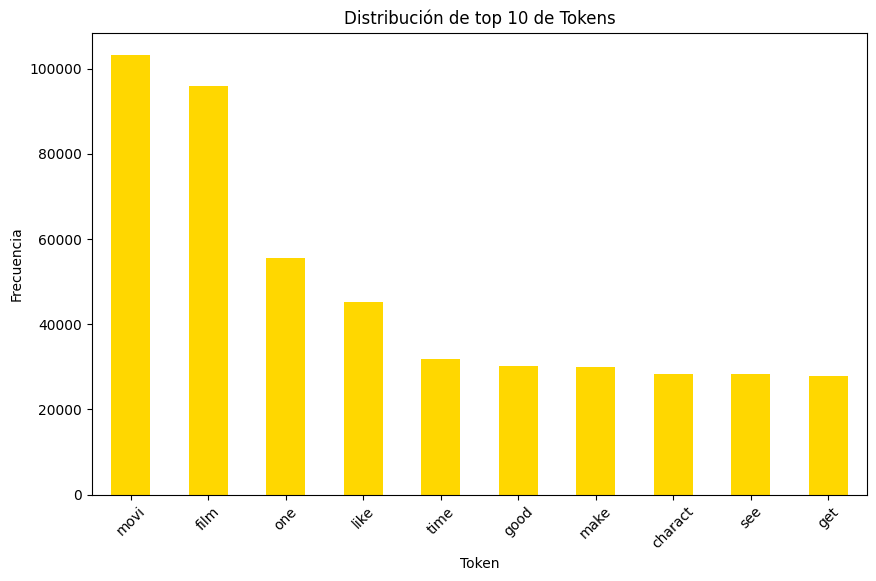

In [130]:
### Visualizacion gráfica del top 10 de tokens más frecuentes

counts = df['tokens'].value_counts().head(10)

counts.plot(kind='bar', figsize=(10, 6), color = ['gold'])
plt.xlabel('Token')
plt.xticks(rotation = 45)
plt.ylabel('Frecuencia')
plt.title('Distribución de top 10 de Tokens')

plt.show()

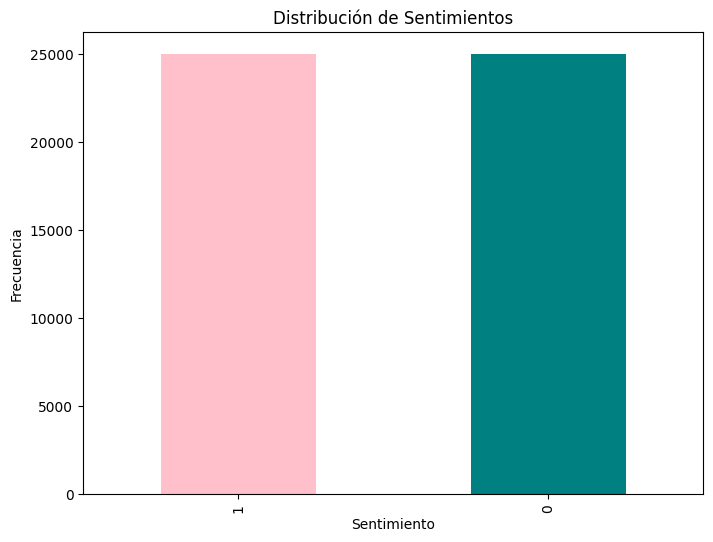

In [131]:
### Distribución de sentimientos

sentiment_count = text_original['sentimento'].value_counts()

sentiment_count.plot(kind='bar', figsize=(8, 6), color=['pink', 'teal'])
plt.xlabel('Sentimiento')
plt.ylabel('Frecuencia')
plt.title('Distribución de Sentimientos')
plt.show()


### Nube de palabras

In [132]:
from wordcloud import WordCloud

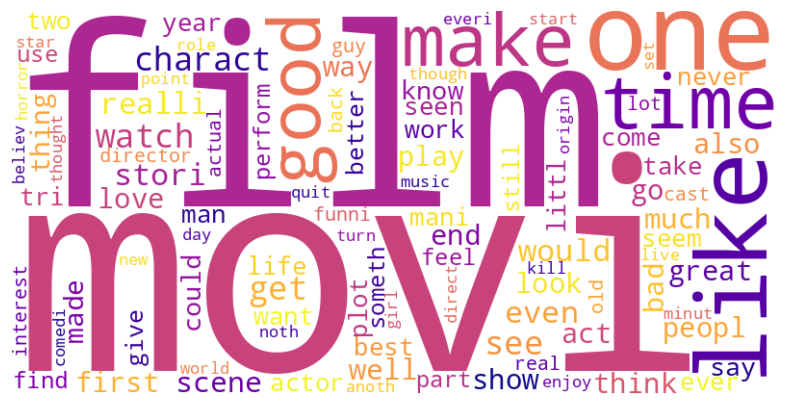

In [133]:
### Obtener frecuencias de los tokens
freq = df['tokens'].value_counts().to_dict()

### Generar nube de palabras con frecuencias
wordcloud = WordCloud(
                      width=800
                      ,height=400
                      ,background_color='white'
                      ,colormap='plasma'
                      ,max_words=100
                      ).generate_from_frequencies(freq)

### Mostrar nube de palabras
plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()


## **4. Representaciones vectoriales de texto**

### **4.1 Bag of Words y técnicas de clasificación**

In [136]:
!pip install sklearn-crfsuite

In [137]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score, roc_curve, accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn_crfsuite import metrics
from sklearn.metrics import classification_report


 **Bag of words**


In [140]:
### Bag of words

vectorizer = CountVectorizer(ngram_range=(1,1), stop_words="english", max_features=20000)
X = vectorizer.fit_transform(text_original['review_cleaned'])

sum_words = X.sum(axis=0)
words_freq = [(word, sum_words[0, idx]) for word, idx in vectorizer.vocabulary_.items()]
words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)

words_freq[:20]

[('movi', np.int64(103241)),
 ('film', np.int64(95853)),
 ('like', np.int64(45197)),
 ('time', np.int64(31953)),
 ('good', np.int64(30179)),
 ('make', np.int64(30020)),
 ('charact', np.int64(28347)),
 ('watch', np.int64(27873)),
 ('stori', np.int64(25272)),
 ('realli', np.int64(23090)),
 ('scene', np.int64(21434)),
 ('look', np.int64(19945)),
 ('end', np.int64(19091)),
 ('bad', np.int64(18532)),
 ('great', np.int64(18395)),
 ('peopl', np.int64(18378)),
 ('love', np.int64(18218)),
 ('think', np.int64(17543)),
 ('act', np.int64(17481)),
 ('play', np.int64(17370))]

In [141]:
### División de frases, con 80% para entrenamiento, 20% para test

X_train, X_test, y_train, y_test = train_test_split(
                                                    X
                                                    ,text_original['sentimento']
                                                    ,test_size=0.2
                                                    ,random_state=42
                                                    )

#### **Modelo Multinomial Naive Bayes**

In [142]:
naive_bayes = MultinomialNB()
naive_bayes.fit(X_train, y_train)

y_pred = naive_bayes.predict(X_test)

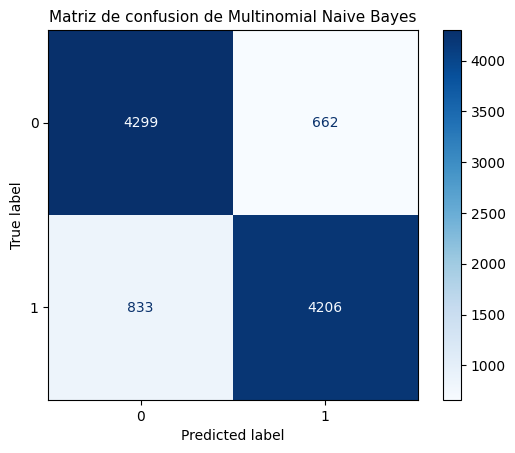

In [203]:
### Matriz de confusion de Multinomial Naive Bayes

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=naive_bayes.classes_)

disp.plot(cmap=plt.cm.Blues)
plt.title('Matriz de confusion de Multinomial Naive Bayes', fontsize = 11)
plt.show()

In [204]:
### Reporte de clasificación

print(classification_report(y_test, y_pred, digits=3))

              precision    recall  f1-score   support

           0      0.838     0.867     0.852      4961
           1      0.864     0.835     0.849      5039

    accuracy                          0.851     10000
   macro avg      0.851     0.851     0.850     10000
weighted avg      0.851     0.851     0.850     10000



#### **Modelo SVM**

In [145]:
svm = LinearSVC()
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


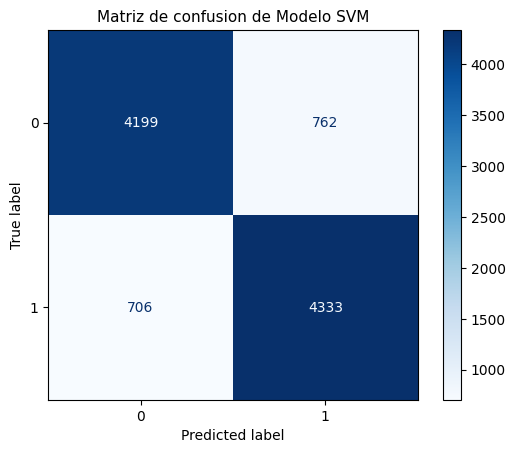

In [205]:
### Matriz de confusion de Modelo SVM

cm_SVM = confusion_matrix(y_test, y_pred_svm)
disp = ConfusionMatrixDisplay(confusion_matrix = cm_SVM, display_labels=naive_bayes.classes_)

disp.plot(cmap = plt.cm.Blues)
plt.title('Matriz de confusion de Modelo SVM', fontsize = 11)
plt.show()

In [206]:
### Reporte de clasificación SVM

print(classification_report(y_test, y_pred_svm, digits=3))

              precision    recall  f1-score   support

           0      0.856     0.846     0.851      4961
           1      0.850     0.860     0.855      5039

    accuracy                          0.853     10000
   macro avg      0.853     0.853     0.853     10000
weighted avg      0.853     0.853     0.853     10000



#### **Random Forest**

In [148]:
random_forest = RandomForestClassifier( n_estimators=300
                                       ,max_depth=None
                                       ,n_jobs=-1
                                       ,random_state=42
                                       )

random_forest.fit(X_train, y_train)
y_pred_rf = random_forest.predict(X_test)

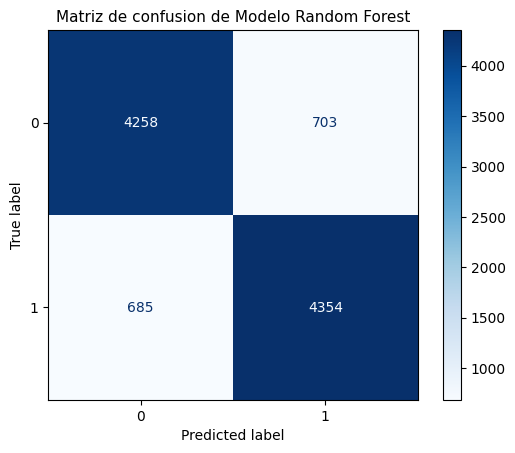

In [149]:
### Matriz de confusion de Modelo Random Forest

rf_SVM = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix = rf_SVM, display_labels=naive_bayes.classes_)

disp.plot(cmap = plt.cm.Blues)
plt.title('Matriz de confusion de Modelo Random Forest', fontsize = 11)
plt.show()

In [190]:
### Reporte de clasificación de Modelo Random Forest

print(classification_report(y_test, y_pred_rf, digits=3))

              precision    recall  f1-score   support

           0      0.861     0.858     0.860      4961
           1      0.861     0.864     0.863      5039

    accuracy                          0.861     10000
   macro avg      0.861     0.861     0.861     10000
weighted avg      0.861     0.861     0.861     10000



#### **K‑Nearest Neighbors (KNN)**

In [151]:
knn = KNeighborsClassifier( n_neighbors=5
                           ,weights = 'distance'
                           ,n_jobs = -1
                          )

knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)


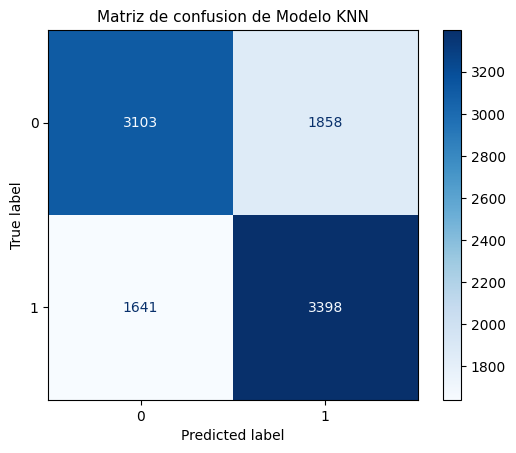

In [207]:
### Matriz de confusion de Modelo KNN

cm_KNN = confusion_matrix(y_test, y_pred_knn)
disp = ConfusionMatrixDisplay(confusion_matrix = cm_KNN, display_labels = naive_bayes.classes_)

disp.plot(cmap = plt.cm.Blues)
plt.title('Matriz de confusion de Modelo KNN', fontsize = 11)
plt.show()

In [208]:
### Reporte de clasificación de Modelo KNN

print(classification_report(y_test, y_pred_knn, digits=3))

              precision    recall  f1-score   support

           0      0.654     0.625     0.639      4961
           1      0.646     0.674     0.660      5039

    accuracy                          0.650     10000
   macro avg      0.650     0.650     0.650     10000
weighted avg      0.650     0.650     0.650     10000



#### **Logistic Regression**

In [157]:
log_reg = LogisticRegression( max_iter=2000
                             ,n_jobs=-1
                             ,C=1.0
                            )

log_reg.fit(X_train, y_train)
y_pred_lr = log_reg.predict(X_test)

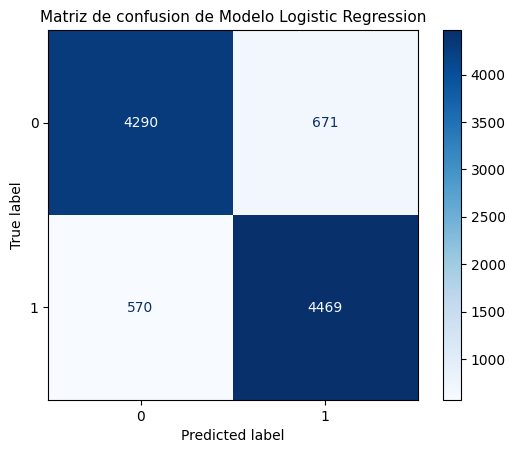

In [158]:
### Matriz de confusion de Logistic Regression

cm_LR = confusion_matrix(y_test, y_pred_lr)
disp = ConfusionMatrixDisplay(confusion_matrix = cm_LR, display_labels = naive_bayes.classes_)

disp.plot(cmap = plt.cm.Blues)
plt.title('Matriz de confusion de Modelo Logistic Regression', fontsize = 11)
plt.show()

In [192]:
### Reporte de clasificación Logistic Regression

print(classification_report(y_test, y_pred_lr, digits=3))

              precision    recall  f1-score   support

           0      0.883     0.865     0.874      4961
           1      0.869     0.887     0.878      5039

    accuracy                          0.876     10000
   macro avg      0.876     0.876     0.876     10000
weighted avg      0.876     0.876     0.876     10000



Visualización de resultado de matrices

In [209]:

print('Matrices de confusión por modelo\n')

print('Matriz de Multinomial Naive Bayes:\n', cm)
print('Matriz de Modelo SVM: \n ', cm_SVM)
print('Matriz de Random Forest: \n ', rf_SVM)
print('Matriz de KNN: \n', cm_KNN)
print('Matriz de Logistic Regression: \n', cm_LR)

Matrices de confusión por modelo

Matriz de Multinomial Naive Bayes:
 [[4299  662]
 [ 833 4206]]
Matriz de Modelo SVM: 
  [[4199  762]
 [ 706 4333]]
Matriz de Random Forest: 
  [[4258  703]
 [ 685 4354]]
Matriz de KNN: 
 [[3103 1858]
 [1641 3398]]
Matriz de Logistic Regression: 
 [[4290  671]
 [ 570 4469]]


### **4.2 TF-IDF y técnicas de clasificación**

In [182]:
### Implementar TF-IDF

vectorizer_TFIDF = TfidfVectorizer( stop_words = 'english'
                                    ,max_features = 20000
                                    ,ngram_range = (1,2)
                                    )

X_tf = vectorizer_TFIDF.fit_transform(text_original['review_cleaned'])

In [183]:
### División de frases para TF-IDF, con 80% para entrenamiento, 20% para test

X_train, X_test, y_train, y_test = train_test_split(
                                                    X_tf
                                                    ,text_original['sentimento']
                                                    ,test_size=0.2
                                                    ,random_state=42
                                                    )

#### **Modelo Multinomial Naive Bayes**

In [184]:
nb_TF = MultinomialNB()
nb_TF.fit(X_train, y_train)

y_pred_TF_NB = nb_TF.predict(X_test)

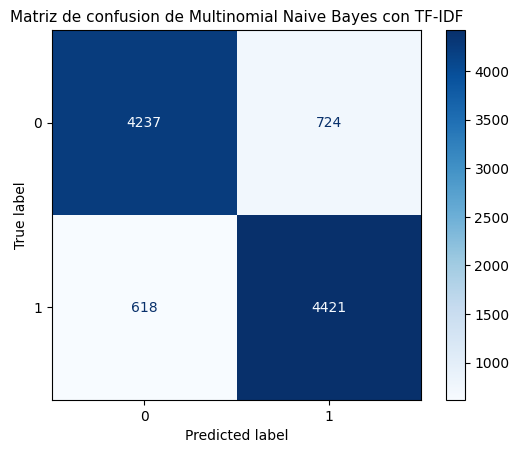

In [200]:
### Matriz de confusion de Multinomial Naive Bayes para TF-IDF

cm_TF = confusion_matrix(y_test, y_pred_TF_NB)
disp = ConfusionMatrixDisplay(confusion_matrix = cm_TF, display_labels = naive_bayes.classes_)

disp.plot(cmap = plt.cm.Blues)
plt.title('Matriz de confusion de Multinomial Naive Bayes con TF-IDF', fontsize = 11)
plt.show()

In [187]:
### Reporte de clasificación de Multinomial Naive Bayes para TF-IDF

print(classification_report(y_test, y_pred_TF_NB, digits=3))

              precision    recall  f1-score   support

           0      0.873     0.854     0.863      4961
           1      0.859     0.877     0.868      5039

    accuracy                          0.866     10000
   macro avg      0.866     0.866     0.866     10000
weighted avg      0.866     0.866     0.866     10000



#### **Modelo SVM**

In [194]:
svm_TF = LinearSVC()
svm_TF.fit(X_train, y_train)

y_pred_TF_svm = svm_TF.predict(X_test)

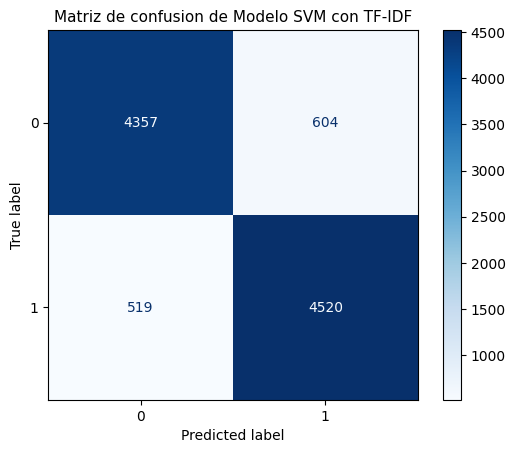

In [201]:
### Matriz de confusion de Modelo SVM

cm_TF_SVM = confusion_matrix(y_test, y_pred_TF_svm)
disp = ConfusionMatrixDisplay(confusion_matrix = cm_TF_SVM, display_labels=naive_bayes.classes_)

disp.plot(cmap = plt.cm.Blues)
plt.title('Matriz de confusion de Modelo SVM con TF-IDF', fontsize = 11)
plt.show()

In [197]:
### Reporte de clasificación SVM

print(classification_report(y_test, y_pred_TF_svm, digits=3))

              precision    recall  f1-score   support

           0      0.894     0.878     0.886      4961
           1      0.882     0.897     0.890      5039

    accuracy                          0.888     10000
   macro avg      0.888     0.888     0.888     10000
weighted avg      0.888     0.888     0.888     10000



#### **Random Forest**

In [198]:
random_forest_TF = RandomForestClassifier( n_estimators=300
                                       ,max_depth=None
                                       ,n_jobs=-1
                                       ,random_state=42
                                       )

random_forest_TF.fit(X_train, y_train)
y_pred_TF_rf = random_forest_TF.predict(X_test)

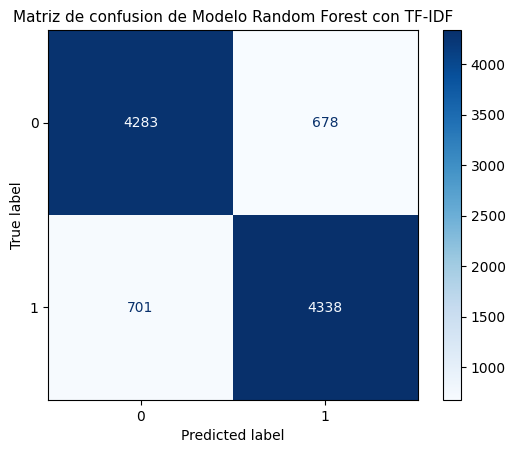

In [202]:
### Matriz de confusion de Modelo Random Forest

rf_TF = confusion_matrix(y_test, y_pred_TF_rf)
disp = ConfusionMatrixDisplay(confusion_matrix = rf_TF, display_labels=naive_bayes.classes_)

disp.plot(cmap = plt.cm.Blues)
plt.title('Matriz de confusion de Modelo Random Forest con TF-IDF', fontsize = 11)
plt.show()

In [210]:
### Reporte de clasificación de Modelo Random Forest

print(classification_report(y_test, y_pred_TF_rf, digits=3))

              precision    recall  f1-score   support

           0      0.859     0.863     0.861      4961
           1      0.865     0.861     0.863      5039

    accuracy                          0.862     10000
   macro avg      0.862     0.862     0.862     10000
weighted avg      0.862     0.862     0.862     10000



#### **K‑Nearest Neighbors (KNN)**

In [211]:
knn_TF = KNeighborsClassifier( n_neighbors=5
                              ,weights = 'distance'
                              ,n_jobs = -1
                              )

knn_TF.fit(X_train, y_train)
y_pred_TF_knn = knn_TF.predict(X_test)


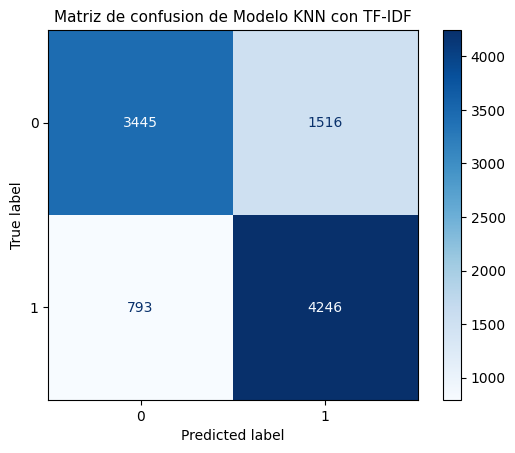

In [212]:
### Matriz de confusion de Modelo KNN

knn_SVM = confusion_matrix(y_test, y_pred_TF_knn)
disp = ConfusionMatrixDisplay(confusion_matrix = knn_SVM, display_labels = naive_bayes.classes_)

disp.plot(cmap = plt.cm.Blues)
plt.title('Matriz de confusion de Modelo KNN con TF-IDF', fontsize = 11)
plt.show()


In [214]:
### Reporte de clasificación de Modelo KNN

print(classification_report(y_test, y_pred_TF_knn, digits=3))

              precision    recall  f1-score   support

           0      0.813     0.694     0.749      4961
           1      0.737     0.843     0.786      5039

    accuracy                          0.769     10000
   macro avg      0.775     0.769     0.768     10000
weighted avg      0.775     0.769     0.768     10000



#### **Logistic Regression**

In [215]:
logreg_TF = LogisticRegression( max_iter=2000
                               ,n_jobs=-1
                               ,C=1.0
                               )

logreg_TF.fit(X_train, y_train)
y_pred_TF_lr = log_reg.predict(X_test)

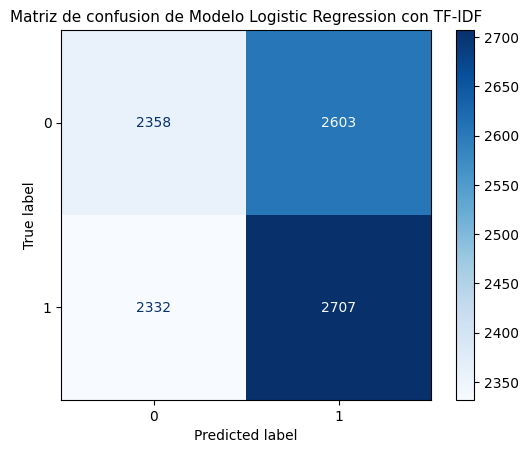

In [218]:
### Matriz de confusion de Logistic Regression

TF_lg = confusion_matrix(y_test, y_pred_TF_lr)
disp = ConfusionMatrixDisplay(confusion_matrix = TF_lg, display_labels = naive_bayes.classes_)

disp.plot(cmap = plt.cm.Blues)
plt.title('Matriz de confusion de Modelo Logistic Regression con TF-IDF', fontsize = 11)
plt.show()

In [217]:
### Reporte de clasificación de Modelo KNN

print(classification_report(y_test, y_pred_TF_lr, digits=3))

              precision    recall  f1-score   support

           0      0.503     0.475     0.489      4961
           1      0.510     0.537     0.523      5039

    accuracy                          0.506     10000
   macro avg      0.506     0.506     0.506     10000
weighted avg      0.506     0.506     0.506     10000

